# Chronos forecasting

The paper behind this approach is here: https://arxiv.org/pdf/2403.07815 (univariate models)

The paper introduces Chronos, a framework that adapts language model architectures for time series forecasting. The key aspects are:

1. Approach:
- Converts time series data into tokens through scaling and quantization
- Uses existing transformer language model architectures with minimal modifications
- Trains models on both real and synthetic time series data

2. Key Components:
- TSMixup: Data augmentation technique that combines patterns from different time series
- KernelSynth: Synthetic data generation using Gaussian processes
- Based on T5 transformer architecture, with models ranging from 20M to 710M parameters

3. Main Results:
- Significantly outperforms traditional statistical models and task-specific deep learning models on in-domain datasets
- Achieves competitive zero-shot performance on unseen datasets compared to models specifically trained on those datasets
- Fine-tuning further improves performance on new datasets

4. Key Benefits:
- Eliminates need for task-specific training
- Simplifies forecasting pipelines
- Shows language model architectures can handle time series without specialized modifications
- Provides strong zero-shot forecasting capabilities

5. Limitations:
- Inference speed slower than some specialized models
- Edge cases with very sparse or high-variance time series
- Limited by available high-quality public time series data

The paper demonstrates that language model architectures can be effectively adapted for time series forecasting with minimal modifications, potentially simplifying real-world forecasting applications.

Chronos-2 was released in October 2025: https://www.amazon.science/blog/introducing-chronos-2-from-univariate-to-universal-forecasting. It now supports **multivariate forecasting**.

1. See Chronos: https://github.com/amazon-science/chronos-forecasting
2. Docs: https://auto.gluon.ai/stable/tutorials/timeseries/forecasting-chronos.html

In [1]:
%%time
!pip install chronos-forecasting

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.3/67.3 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.3/139.3 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.2/14.2 MB 139.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.7/85.7 kB 8.6 MB/s eta 0:00:00
CPU times: user 1.91 s, sys: 281 ms, total: 2.19 s
Wall time: 16.1 s


## Set Up

In [2]:
import pandas as pd  # requires: pip install pandas
import torch
from chronos import BaseChronosPipeline
import matplotlib.pyplot as plt  # requires: pip install matplotlib
import numpy as np

pipeline = BaseChronosPipeline.from_pretrained(
    "amazon/chronos-t5-small",  # use "amazon/chronos-bolt-small" for the corresponding Chronos-Bolt model
    device_map="cuda",  # use "cpu" for CPU inference
    torch_dtype=torch.bfloat16,
)



/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/185M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/142 [00:00<?, ?B/s]

## Forecasting Passenger Traffic

In [3]:
df = pd.read_csv(
    "https://raw.githubusercontent.com/AileenNielsen/TimeSeriesAnalysisWithPython/master/data/AirPassengers.csv"
)

# context must be either a 1D tensor, a list of 1D tensors,
# or a left-padded 2D tensor with batch as the first dimension
# quantiles is an fp32 tensor with shape [batch_size, prediction_length, num_quantile_levels]
# mean is an fp32 tensor with shape [batch_size, prediction_length]
quantiles, mean = pipeline.predict_quantiles(
    inputs=torch.tensor(df["#Passengers"]),
    prediction_length=12,
    quantile_levels=[0.1, 0.5, 0.9],
)

In [4]:
df.head()

,Month,#Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [5]:
df.tail()

,Month,#Passengers
139,1960-08,606
140,1960-09,508
141,1960-10,461
142,1960-11,390
143,1960-12,432


In [6]:
from chronos import ChronosPipeline, ChronosBoltPipeline

print(ChronosPipeline.predict.__doc__)  # for Chronos models
print(ChronosBoltPipeline.predict.__doc__)  # for Chronos-Bolt models


        Get forecasts for the given time series.

        Refer to the base method (``BaseChronosPipeline.predict``)
        for details on shared parameters.

        Additional parameters
        ---------------------
        num_samples
            Number of sample paths to predict. Defaults to what
            specified in ``self.model.config``.
        temperature
            Temperature to use for generating sample tokens.
            Defaults to what specified in ``self.model.config``.
        top_k
            Top-k parameter to use for generating sample tokens.
            Defaults to what specified in ``self.model.config``.
        top_p
            Top-p parameter to use for generating sample tokens.
            Defaults to what specified in ``self.model.config``.
        limit_prediction_length
            Force prediction length smaller or equal than the
            built-in prediction length from the model. False by
            default. When true, fail loudly if longer p

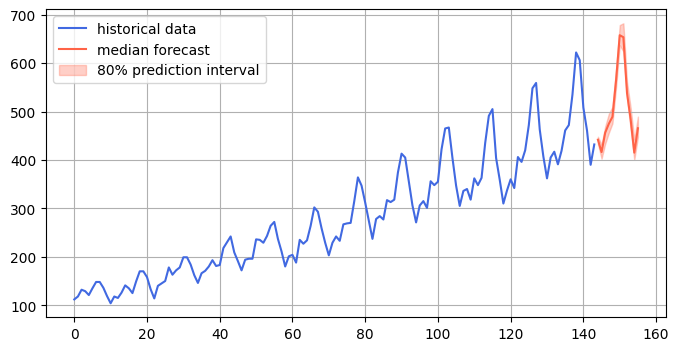

In [7]:
forecast_index = range(len(df), len(df) + 12)
low, median, high = quantiles[0, :, 0], quantiles[0, :, 1], quantiles[0, :, 2]

plt.figure(figsize=(8, 4))
plt.plot(df["#Passengers"], color="royalblue", label="historical data")
plt.plot(forecast_index, median, color="tomato", label="median forecast")
plt.fill_between(forecast_index, low, high, color="tomato", alpha=0.3, label="80% prediction interval")
plt.legend()
plt.grid()
plt.show()


## Forecasting Stock Prices

In [8]:
# Code to use yfinance to download bitcoin data from FRED ticker CBBTCUSD

!pip install yfinance

import yfinance as yf

In [9]:
# Download Stock data
df = yf.download("GOOGL", start="2023-08-31", end="2025-11-01")

# Print the downloaded data
df.head()


/tmp/ipython-input-375105660.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("GOOGL", start="2023-08-31", end="2025-11-01")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,GOOGL,GOOGL,GOOGL,GOOGL,GOOGL
Date,,,,,
2023-08-31,135.237244,137.054710,134.859842,135.078336,30053800
2023-09-01,134.730743,136.518417,133.926294,136.518417,21543700
2023-09-05,134.840012,135.485553,133.658160,134.512270,19403100
2023-09-06,133.538971,135.594784,132.754374,135.088283,18684500
2023-09-07,134.333481,134.651296,132.039306,132.674922,18844300


In [10]:
f_len = 32
col_name = 'Close'

quantiles, mean = pipeline.predict_quantiles(
    inputs=torch.tensor(df[col_name].dropna().values[-126:]), # Convert the Pandas Series to a NumPy array and drop NaN values before creating the tensor
    prediction_length=f_len,
    quantile_levels=[0.1, 0.5, 0.9],
)

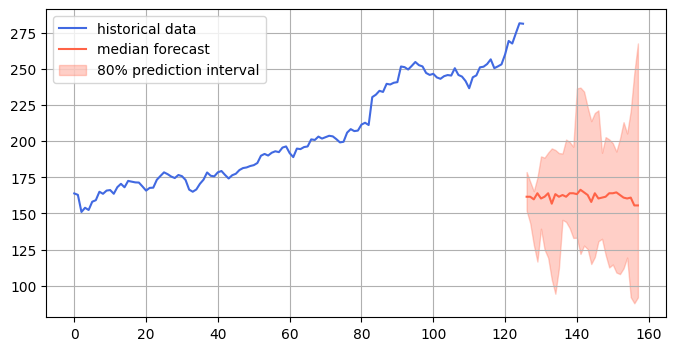

In [11]:
forecast_index = range(len(df[-126:]), len(df[-126:]) + f_len)
low, median, high = quantiles[0, :, 0], quantiles[0, :, 1], quantiles[0, :, 2]

plt.figure(figsize=(8, 4))
plt.plot(np.array(df[col_name][-126:]), color="royalblue", label="historical data")
plt.plot(forecast_index, median, color="tomato", label="median forecast")
plt.fill_between(forecast_index, low, high, color="tomato", alpha=0.3, label="80% prediction interval")
plt.legend()
plt.grid()
plt.show()

## Stock Returns

In [12]:
f_len = 21
col_name = 'Close'
ts = df[col_name].pct_change().dropna().values

quantiles, mean = pipeline.predict_quantiles(
    inputs=torch.tensor(ts), # Convert the Pandas Series to a NumPy array and drop NaN values before creating the tensor
    prediction_length=f_len,
    quantile_levels=[0.1, 0.5, 0.9],
)

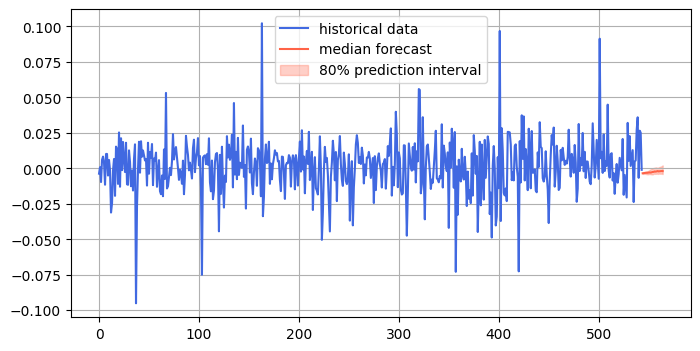

In [13]:
forecast_index = range(len(ts), len(ts) + f_len)
low, median, high = quantiles[0, :, 0], quantiles[0, :, 1], quantiles[0, :, 2]

plt.figure(figsize=(8, 4))
plt.plot(np.array(ts), color="royalblue", label="historical data")
plt.plot(forecast_index, median, color="tomato", label="median forecast")
plt.fill_between(forecast_index, low, high, color="tomato", alpha=0.3, label="80% prediction interval")
plt.legend()
plt.grid()
plt.show()

## Treasuries (10 yr)

In [ ]:
df = pd.read_csv('https://fred.stlouisfed.org/graph/fredgraph.csv?bgcolor=%23ebf3fb&chart_type=line&drp=0&fo=open%20sans&graph_bgcolor=%23ffffff&height=450&mode=fred&recession_bars=on&txtcolor=%23444444&ts=12&tts=12&width=1320&nt=0&thu=0&trc=0&show_legend=yes&show_axis_titles=yes&show_tooltip=yes&id=DFII10&scale=left&cosd=2020-03-20&coed=2025-03-20&line_color=%230073e6&link_values=false&line_style=solid&mark_type=none&mw=3&lw=3&ost=-99999&oet=99999&mma=0&fml=a&fq=Daily&fam=avg&fgst=lin&fgsnd=2020-02-01&line_index=1&transformation=lin&vintage_date=2025-03-21&revision_date=2025-03-21&nd=2003-01-02')
df.head()

,observation_date,DFII10
0,2020-03-20,0.17
1,2020-03-23,-0.04
2,2020-03-24,-0.13
3,2020-03-25,-0.19
4,2020-03-26,-0.24


In [ ]:
f_len = 64
col_name = 'DFII10'

quantiles, mean = pipeline.predict_quantiles(
    inputs=torch.tensor(df[col_name].dropna().values), # Convert the Pandas Series to a NumPy array and drop NaN values before creating the tensor
    prediction_length=f_len,
    quantile_levels=[0.1, 0.5, 0.9],
)

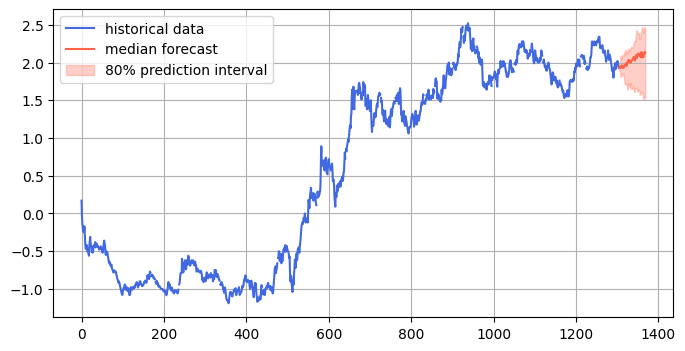

In [ ]:
forecast_index = range(len(df), len(df) + f_len)
low, median, high = quantiles[0, :, 0], quantiles[0, :, 1], quantiles[0, :, 2]

plt.figure(figsize=(8, 4))
plt.plot(np.array(df[col_name]), color="royalblue", label="historical data")
plt.plot(forecast_index, median, color="tomato", label="median forecast")
plt.fill_between(forecast_index, low, high, color="tomato", alpha=0.3, label="80% prediction interval")
plt.legend()
plt.grid()
plt.show()

## Cryptocurrencies

In [ ]:
df = pd.read_csv('https://fred.stlouisfed.org/graph/fredgraph.csv?bgcolor=%23ebf3fb&chart_type=line&drp=0&fo=open%20sans&graph_bgcolor=%23ffffff&height=450&mode=fred&recession_bars=on&txtcolor=%23444444&ts=12&tts=12&width=1320&nt=0&thu=0&trc=0&show_legend=yes&show_axis_titles=yes&show_tooltip=yes&id=CBBTCUSD&scale=left&cosd=2020-03-20&coed=2025-03-20&line_color=%230073e6&link_values=false&line_style=solid&mark_type=none&mw=3&lw=3&ost=-99999&oet=99999&mma=0&fml=a&fq=Daily%2C%207-Day&fam=avg&fgst=lin&fgsnd=2020-02-01&line_index=1&transformation=lin&vintage_date=2025-03-21&revision_date=2025-03-21&nd=2014-12-01')
df.head()

,observation_date,CBBTCUSD
0,2020-03-20,6215.40
1,2020-03-21,6168.72
2,2020-03-22,5791.69
3,2020-03-23,6583.38
4,2020-03-24,6742.21


In [ ]:
f_len = 64
col_name = 'CBBTCUSD'

quantiles, mean = pipeline.predict_quantiles(
    inputs=torch.tensor(df[col_name].dropna().values), # Convert the Pandas Series to a NumPy array and drop NaN values before creating the tensor
    prediction_length=f_len,
    quantile_levels=[0.1, 0.5, 0.9],
)

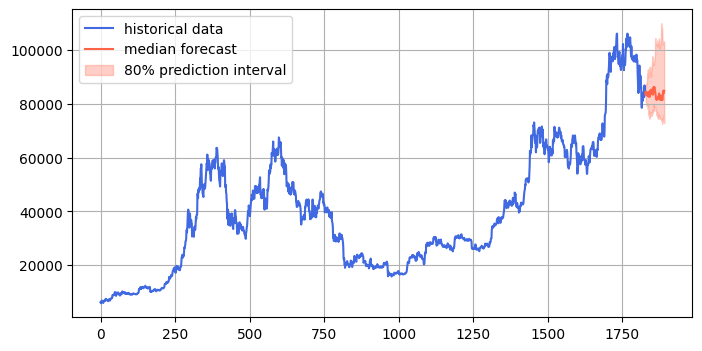

In [ ]:
forecast_index = range(len(df), len(df) + f_len)
low, median, high = quantiles[0, :, 0], quantiles[0, :, 1], quantiles[0, :, 2]

plt.figure(figsize=(8, 4))
plt.plot(np.array(df[col_name]), color="royalblue", label="historical data")
plt.plot(forecast_index, median, color="tomato", label="median forecast")
plt.fill_between(forecast_index, low, high, color="tomato", alpha=0.3, label="80% prediction interval")
plt.legend()
plt.grid()
plt.show()

## Chronos-2

This is for multivariate forecasting. See the technical paper: https://arxiv.org/abs/2510.15821

GitHub: https://github.com/amazon-science/chronos-forecasting

Let's try the example provided:

In [ ]:
import pandas as pd  # requires: pip install 'pandas[pyarrow]'
from chronos import Chronos2Pipeline

pipeline = Chronos2Pipeline.from_pretrained("amazon/chronos-2", device_map="cuda")

# Load historical target values and past values of covariates
context_df = pd.read_parquet("https://autogluon.s3.amazonaws.com/datasets/timeseries/electricity_price/train.parquet")

# (Optional) Load future values of covariates
test_df = pd.read_parquet("https://autogluon.s3.amazonaws.com/datasets/timeseries/electricity_price/test.parquet")
future_df = test_df.drop(columns="target")

# Generate predictions with covariates
pred_df = pipeline.predict_df(
    context_df,
    future_df=future_df,
    prediction_length=24,  # Number of steps to forecast
    quantile_levels=[0.1, 0.5, 0.9],  # Quantile for probabilistic forecast
    id_column="id",  # Column identifying different time series
    timestamp_column="timestamp",  # Column with datetime information
    target="target",  # Column(s) with time series values to predict
)

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/478M [00:00<?, ?B/s]

In [ ]:
context_df.head()

,id,timestamp,target,Ampirion Load Forecast,PV+Wind Forecast
0,DE,2012-01-09 00:00:00,34.970001,16382.00,3569.527588
1,DE,2012-01-09 01:00:00,33.430000,15410.50,3315.274902
2,DE,2012-01-09 02:00:00,32.740002,15595.00,3107.307617
3,DE,2012-01-09 03:00:00,32.459999,16521.00,2944.620117
4,DE,2012-01-09 04:00:00,32.500000,17700.75,2897.149902


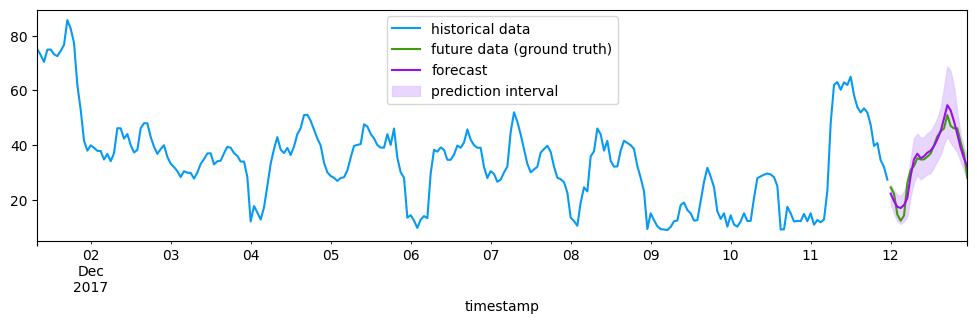

In [ ]:
import matplotlib.pyplot as plt  # requires: pip install matplotlib

ts_context = context_df.set_index("timestamp")["target"].tail(256)
ts_pred = pred_df.set_index("timestamp")
ts_ground_truth = test_df.set_index("timestamp")["target"]

ts_context.plot(label="historical data", color="xkcd:azure", figsize=(12, 3))
ts_ground_truth.plot(label="future data (ground truth)", color="xkcd:grass green")
ts_pred["predictions"].plot(label="forecast", color="xkcd:violet")
plt.fill_between(
    ts_pred.index,
    ts_pred["0.1"],
    ts_pred["0.9"],
    alpha=0.7,
    label="prediction interval",
    color="xkcd:light lavender",
)
plt.legend()

## Compare to univariate forecast

Drop all additional data and only keep the target series.

In [ ]:
context_df = context_df[["id", "timestamp", "target"]]
test_df = test_df[["id", "timestamp", "target"]]
future_df = test_df.drop(columns="target")

In [ ]:
pred_df = pipeline.predict_df(
    context_df,
    future_df=future_df,
    prediction_length=24,  # Number of steps to forecast
    quantile_levels=[0.1, 0.5, 0.9],  # Quantile for probabilistic forecast
    id_column="id",  # Column identifying different time series
    timestamp_column="timestamp",  # Column with datetime information
    target="target",  # Column(s) with time series values to predict
)

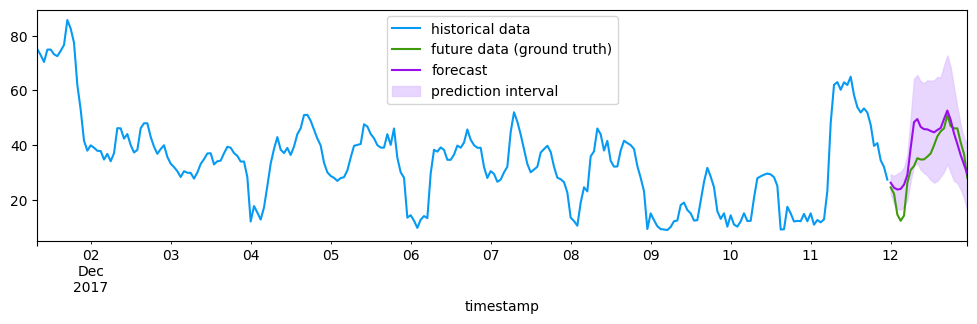

In [ ]:
ts_context = context_df.set_index("timestamp")["target"].tail(256)
ts_pred = pred_df.set_index("timestamp")
ts_ground_truth = test_df.set_index("timestamp")["target"]

ts_context.plot(label="historical data", color="xkcd:azure", figsize=(12, 3))
ts_ground_truth.plot(label="future data (ground truth)", color="xkcd:grass green")
ts_pred["predictions"].plot(label="forecast", color="xkcd:violet")
plt.fill_between(
    ts_pred.index,
    ts_pred["0.1"],
    ts_pred["0.9"],
    alpha=0.7,
    label="prediction interval",
    color="xkcd:light lavender",
)
plt.legend()

We can see that the forecast error is much higher.

## Multivariate stock price forecast

We download the "magnificent 7" tech stocks: Alphabet, Amazon, Apple, Microsoft, Netflix, Nvidia, Tesla.

In [ ]:
df = yf.download(["GOOGL", "AMZN", "AAPL", "MSFT", "NFLX", "NVDA", "TSLA"],
                  start="2023-08-31", end="2025-11-01")

/tmp/ipython-input-1245906998.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(["GOOGL", "AMZN", "AAPL", "MSFT", "NFLX", "NVDA", "TSLA"],
[*********************100%***********************]  7 of 7 completed


In [ ]:
df.head()

Price            Close                                                 \
Ticker            AAPL        AMZN       GOOGL        MSFT       NFLX   
Date                                                                    
2023-08-31  185.867477  138.009995  135.237244  322.894012  43.368000   
2023-09-01  187.440536  138.119995  134.730759  323.780640  43.987999   
2023-09-05  187.677979  137.270004  134.839981  328.597992  44.868000   
2023-09-06  180.960388  135.360001  133.538986  327.937988  44.576000   
2023-09-07  175.667374  137.850006  134.333496  325.012085  44.313999   

Price                                    High                          ...  \
Ticker           NVDA        TSLA        AAPL        AMZN       GOOGL  ...   
Date                                                                   ...   
2023-08-31  49.321865  258.079987  187.104154  138.789993  137.054710  ...   
2023-09-01  48.476433  245.009995  187.895625  139.960007  136.518432  ...   
2023-09-05  48.515415  256.489990  187.954993  137.800003  135.485523  ...   
2023-09-06  47.033283  251.919998  186.837077  137.449997  135.594799  ...   
2023-09-07  46.213760  251.490005  176.310454  138.029999  134.651311  ...   

Price            Open                            Volume                      \
Ticker           NFLX       NVDA        TSLA       AAPL      AMZN     GOOGL   
Date                                                                          
2023-08-31  43.123001  49.346850  255.979996   60794500  58781300  30053800   
2023-09-01  43.772999  49.728594  257.260010   45766500  40991500  21543700   
2023-09-05  43.839001  48.190633  245.000000   45280000  40636700  19403100   
2023-09-06  44.861000  48.412472  255.139999   81755800  41785500  18684500   
2023-09-07  44.115002  45.498183  245.070007  112488800  48498900  18844300   

Price                                                 
Ticker          MSFT      NFLX       NVDA       TSLA  
Date                                                  
2023-08-31  26411000  38030000  528570000  108861700  
2023-09-01  14942000  47934000  463830000  132541600  
2023-09-05  18553900  61559000  382653000  129469600  
2023-09-06  17535800  38623000  468670000  116959800  
2023-09-07  18381000  29227000  433330000  115312900  

[5 rows x 35 columns]

In [ ]:
df1 = df["Close"].reset_index()
print("Length of series =", len(df))
df1["item_id"] = "D1"

# Convert 'Date' to datetime and set it as index
df1['Date'] = pd.to_datetime(df1['Date'])
df1 = df1.set_index('Date')

# Reindex to business day frequency and forward-fill missing values
df1 = df1.asfreq('B').ffill()

# Reset index to make 'Date' a column again, as predict_df expects it
df1 = df1.reset_index()

df1.head()

Length of series = 545


Ticker,Date,AAPL,AMZN,GOOGL,MSFT,NFLX,NVDA,TSLA,item_id
0,2023-08-31,185.867477,138.009995,135.237244,322.894012,43.368000,49.321865,258.079987,D1
1,2023-09-01,187.440536,138.119995,134.730759,323.780640,43.987999,48.476433,245.009995,D1
2,2023-09-04,187.440536,138.119995,134.730759,323.780640,43.987999,48.476433,245.009995,D1
3,2023-09-05,187.677979,137.270004,134.839981,328.597992,44.868000,48.515415,256.489990,D1
4,2023-09-06,180.960388,135.360001,133.538986,327.937988,44.576000,47.033283,251.919998,D1


In [ ]:
import pandas as pd  # requires: pip install 'pandas[pyarrow]'
from chronos import Chronos2Pipeline

pipeline = Chronos2Pipeline.from_pretrained("amazon/chronos-2", device_map="cuda")

# Load historical target values and past values of covariates
context_df = df1.iloc[:500]

# (Optional) Load future values of covariates
test_df = df1.iloc[500:]
future_df = test_df.drop(columns=["NVDA"]) # Only drop the target column, keep 'item_id'
pred_length = len(test_df)

# Generate predictions with covariates
pred_df = pipeline.predict_df(
    context_df,
    future_df=future_df,
    prediction_length=pred_length,  # Number of steps to forecast
    quantile_levels=[0.1, 0.5, 0.9],  # Quantile for probabilistic forecast
    id_column="item_id",  # Column identifying different time series
    timestamp_column="Date",  # Column with datetime information
    target="NVDA",  # Column(s) with time series values to predict
)

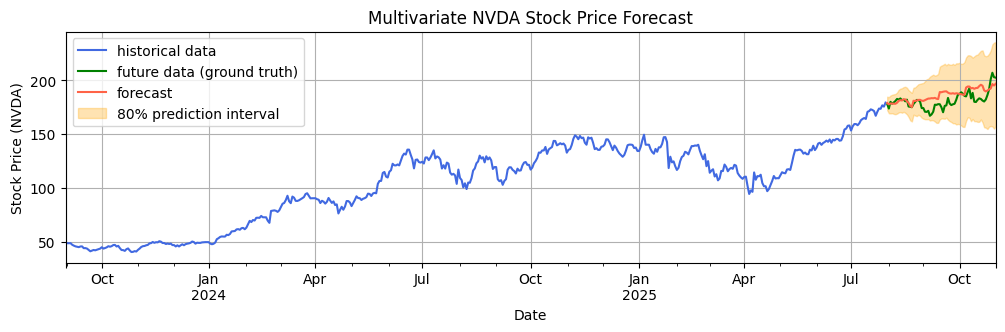

In [ ]:
import matplotlib.pyplot as plt

ts_context = context_df.set_index("Date")["NVDA"]
ts_pred = pred_df.set_index("Date")
ts_ground_truth = test_df.set_index("Date")["NVDA"]

plt.figure(figsize=(12, 3))
ts_context.plot(label="historical data", color="royalblue")
ts_ground_truth.plot(label="future data (ground truth)", color="green")
ts_pred["predictions"].plot(label="forecast", color="tomato")
plt.fill_between(
    ts_pred.index,
    ts_pred["0.1"], # Using '0.1' as the lower quantile column name
    ts_pred["0.9"], # Using '0.9' as the upper quantile column name
    alpha=0.3,
    label="80% prediction interval",
    color="orange",
)
plt.title("Multivariate NVDA Stock Price Forecast")
plt.xlabel("Date")
plt.ylabel("Stock Price (NVDA)")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
print("Mean Absolute Percentage Error (MAPE) =", (abs(ts_ground_truth - ts_pred["predictions"]) / ts_ground_truth).mean())
print("Root Mean Squared Error (RMSE) =", ((ts_ground_truth - ts_pred["predictions"]) ** 2).mean() ** 0.5)

Mean Absolute Percentage Error (MAPE) = 0.03533941370091254
Root Mean Squared Error (RMSE) = 8.092790535852734


In [ ]:
# Univariate forecast?
context_df = context_df[["item_id", "Date", "NVDA"]]
test_df = test_df[["item_id", "Date", "NVDA"]]
future_df = test_df.drop(columns="NVDA")

In [ ]:
pred_df = pipeline.predict_df(
    context_df,
    future_df=future_df,
    prediction_length=pred_length,  # Number of steps to forecast
    quantile_levels=[0.1, 0.5, 0.9],  # Quantile for probabilistic forecast
    id_column="item_id",  # Column identifying different time series
    timestamp_column="Date",  # Column with datetime information
    target="NVDA",  # Column(s) with time series values to predict
)

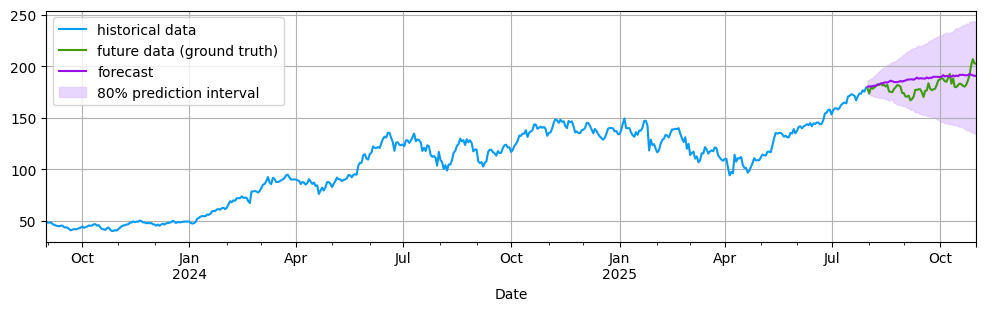

In [ ]:
ts_context = context_df.set_index("Date")["NVDA"]
ts_pred = pred_df.set_index("Date")
ts_ground_truth = test_df.set_index("Date")["NVDA"]

ts_context.plot(label="historical data", color="xkcd:azure", figsize=(12, 3))
ts_ground_truth.plot(label="future data (ground truth)", color="xkcd:grass green")
ts_pred["predictions"].plot(label="forecast", color="xkcd:violet")
plt.fill_between(
    ts_pred.index,
    ts_pred["0.1"],
    ts_pred["0.9"],
    alpha=0.7,
    label="80% prediction interval",
    color="xkcd:light lavender",
)
plt.legend()
plt.grid()

In [ ]:
print("Mean Absolute Percentage Error (MAPE) =", (abs(ts_ground_truth - ts_pred["predictions"]) / ts_ground_truth).mean())
print("Root Mean Squared Error (RMSE) =", ((ts_ground_truth - ts_pred["predictions"]) ** 2).mean() ** 0.5)

Mean Absolute Percentage Error (MAPE) = 0.044511327754015645
Root Mean Squared Error (RMSE) = 9.512994695115095
